# Part 6.2: Robust Tube MPC for Landing (Full System)

In this part, we combine the **Robust Tube MPC** designed for the Z-axis (in Part 6.1) with **Nominal MPC** controllers for the X, Y, and Roll subsystems.

The goal is to land the rocket from an initial state:
$$ x_0 = [x=3, y=2, z=10, \gamma=30^\circ] $$
to a target state:
$$ x_{target} = [x=1, y=0, z=3, \gamma=0^\circ] $$

### Controller Architecture
- **Z-axis**: Robust Tube MPC (handles disturbances and ensures $z \ge 0$).
- **X, Y, Roll axes**: Nominal MPC with Soft Constraints (handles tracking without strict robustness guarantees, sufficient for these axes).

All controllers are implemented using a unified `MPCControl_base` class, where the Z-controller utilizes the tube logic ($E \neq 0, K \neq 0$) and the others use nominal logic ($E=\{0\}, K=0$).

In [2]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import sys, os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [3]:
import time
from LandMPC.MPCLandControl import MPCLandControl
from src.rocket import Rocket, perturb_rocket
from src.pos_rocket_vis import *

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir,"rocket.yaml")

# Rocket setup
Ts  = 1/20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
rocket.mass = 1.7 # Do not change!!!

# Visualization setup
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1

In [4]:
# Simulation parameters
sim_time = 5.0 # simulation length in seconds

# Initial state: [w, phi, v, p]
# w = [0, 0, 0]
# phi = [0, 0, 30 deg] -> [0, 0, 0.5236 rad]
# v = [0, 0, 0]
# p = [3, 2, 10]
x0 = np.array([0, 0, 0, 0, 0, np.deg2rad(30), 0, 0, 0, 3, 2, 10])

# Reference state (Target): [x=1, y=0, z=3, roll=0]
# Note: The reference vector must match the full state size (12)
# Order: [wx, wy, wz, alpha, beta, gamma, vx, vy, vz, x, y, z]
x_ref = np.zeros(12)
x_ref[9] = 1.0  # x
x_ref[10] = 0.0 # y
x_ref[11] = 3.0 # z
# gamma (roll) is 0 by default

# Trim around the target state
xs, us = rocket.trim(x_ref)
print("Linearization around a steady state:")
print("x_ref = ", x_ref)
print("xs = ", xs)
print("us = ", us)

# Linearize system
A, B = rocket.linearize(xs, us)

# MPC parameters
H = 2.0 # Horizon in seconds
# Merge four linear mpc
mpc = MPCLandControl().new_controller(rocket, Ts, H, x_ref=x_ref)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Linearization around a steady state:
x_ref =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
us =  [ 0.          0.         56.66666667  0.        ]
Maximum invariant set successfully computed after 23 iterations.
Maximum invariant set successfully computed after 23 iterations.
Minimal robust invariant set computation converged after 56 iterations.
Maximum invariant set successfully computed after 27 iterations.
Maximum invariant set successfully computed after 35 iterations.


Simulating time 0.00

 State alpha violation: 0.22 > 0.17, 
 State alpha violation: 0.28 > 0.17, 
 State alpha violation: 0.30 > 0.17, 
 State beta violation: -0.20 < -0.17, 
 State alpha violation: 0.29 > 0.17, 
 State beta violation: -0.22 < -0.17, 
 State alpha violation: 0.25 > 0.17, 
 State beta violation: -0.23 < -0.17, 
 State alpha violation: 0.19 > 0.17, 
 State beta violation: -0.22 < -0.17, 
 State beta violation: -0.19 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
 State alpha violation: 0.18 > 0.17, 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
 State beta violation: -0.18 < -0.17, Simulating time 1.00

 State beta violation: -0.18 < -0.17, 
 State beta violation: -0.18 < -0.17, 
 State beta violation: -0.18 < -0.17, 
 State beta violation: -0.18 < -0.17, Simulating time 2.00
Simulating time 3.00
Simulating time 4.00


AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=99, step=2), IntSlider(value=0,…

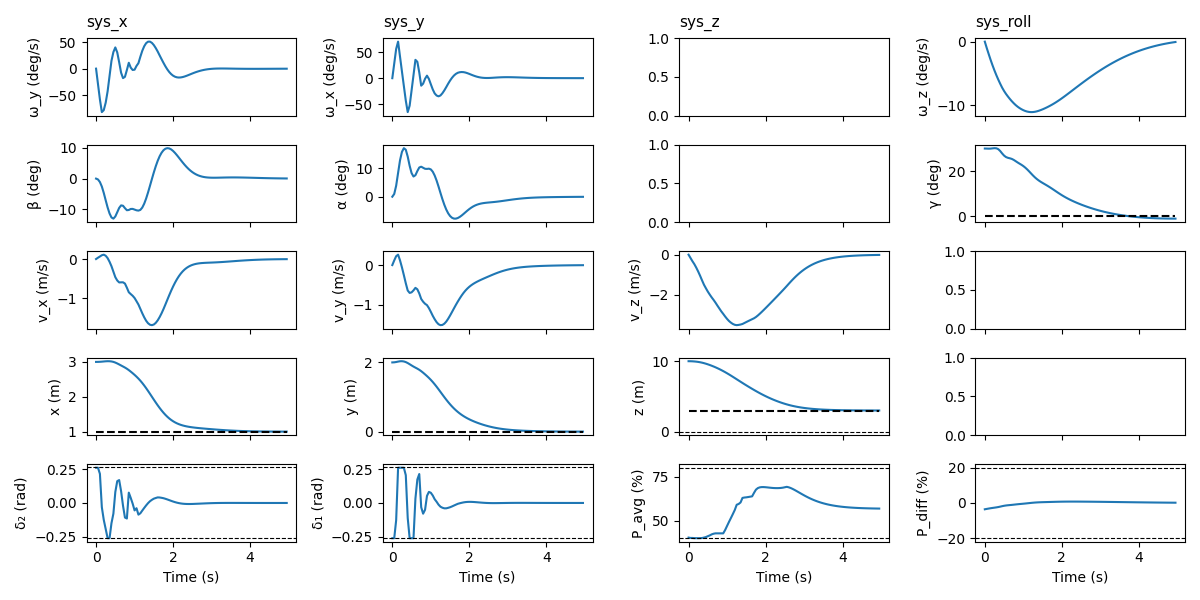

In [5]:
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol = rocket.simulate_land(mpc, sim_time, H, x0)
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol)
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs)

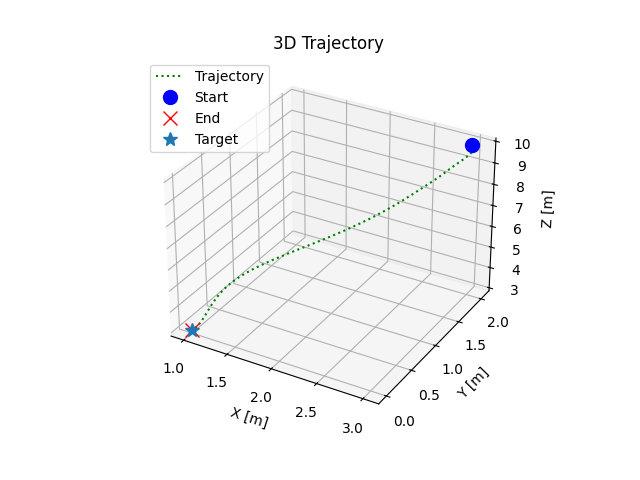

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Indexes for position are likely 9 (x), 10 (y), 11 (z) based on standard 12-state rocket
x_pos = x_cl[9, :-1]
y_pos = x_cl[10, :-1]
z_pos = x_cl[11, :-1]

# Trajectory: Green dotted line
ax.plot(x_pos, y_pos, z_pos, 'g:', label='Trajectory')

# Start position: Blue circle
ax.plot([x0[9]], [x0[10]], [x0[11]], 'bo', markersize=10, label='Start')

# End position: Red cross
ax.plot([x_pos[-1]], [y_pos[-1]], [z_pos[-1]], 'rx', markersize=10, label='End')

# Target position: Star
# x_ref was defined in the notebook as the target state
ax.plot([x_ref[9]], [x_ref[10]], [x_ref[11]], '*', markersize=10, label='Target')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
plt.title('3D Trajectory')
plt.legend()
plt.show()